In [ ]:
# ===========================================
#  SMART LOAN RECOVERY SYSTEM (AI + ML)
#  Compatible with: loan-data.csv
# ===========================================

# ------------------#
#  1. IMPORTS
# ------------------#
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

# ------------------#
#  2. LOAD DATA
# ------------------#
df = pd.read_csv("loan-data.csv")

print("Dataset Loaded Successfully!")
print(df.head())

# ==============================================================
# 3. BASIC CLEANING — Modify According to Loan Dataset Structure
# ==============================================================

# If dataset has missing values, fill or drop
df = df.dropna()  # safest default

# Identify columns
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)

# Dummy Encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# ------------------#
#  4. TARGET COLUMN
# ------------------#

# Your dataset may have "loan_status", "default", "is_default", etc.
# Adjust the target name below to match your file:

possible_targets = ["default", "loan_status", "is_default", "Loan_Status"]

target = None
for col in df.columns:
    if col.lower() in possible_targets:
        target = col
        break

if target is None:
    raise ValueError("❌ Could not find a default indicator column in dataset. Please specify its name.")

print("Using Target Column:", target)

# Ensure binary target
df_encoded[target] = df_encoded[target].apply(lambda x: 1 if str(x).lower() in ["default", "1", "yes", "charged off"] else 0)

# ----------------------------#
#  5. TRAIN/TEST SPLIT
# ----------------------------#
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# ----------------------------#
#  6. TRAIN XGBOOST MODEL
# ----------------------------#
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

preds = model.predict(X_test)
print("\nMODEL PERFORMANCE:")
print(classification_report(y_test, preds))

# Predict Probabilities
df_encoded["default_probability"] = model.predict_proba(X_scaled)[:, 1]

# ==================================================
# 7. CLUSTERING FOR BORROWER BEHAVIOR (Personas)
# ==================================================
kmeans = KMeans(n_clusters=4, random_state=42)
df_encoded["customer_cluster"] = kmeans.fit_predict(X_scaled)

# ------------------------------#
#  8. PRIORITY RECOVERY SCORE
# ------------------------------#

df_encoded["recovery_priority_score"] = (
    df_encoded["default_probability"] * 0.7 +
    (df_encoded["customer_cluster"] / df_encoded["customer_cluster"].max()) * 0.3
)

# Sort Highest Priority First
priority_df = df_encoded.sort_values("recovery_priority_score", ascending=False)

# Keep Only Explainable Columns
output_cols = ["default_probability", "customer_cluster", "recovery_priority_score"]
priority_df_final = pd.concat([df, priority_df[output_cols]], axis=1)

# ------------------------------------#
#  9. EXPORT QUEUE → CSV
# ------------------------------------#
priority_df_final.to_csv("priority_recovery_queue.csv", index=False)

print("\n🎉 priority_recovery_queue.csv GENERATED SUCCESSFULLY!")
print(priority_df_final.head(10))


FileNotFoundError: [Errno 2] No such file or directory: 'loan-data.csv'

In [ ]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving loan-data.csv to loan-data.csv
User uploaded file "loan-data.csv" with length 4264492 bytes


In [ ]:
import pandas as pd

priority_queue_df = pd.read_csv('priority_recovery_queue.csv')
display(priority_queue_df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'priority_recovery_queue.csv'

Rows, cols: (39717, 12)
Columns: ['id', 'loan_amnt', 'term', 'int_rate', 'installment', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'total_pymnt']
Default rate (target): 0.14167736737417227


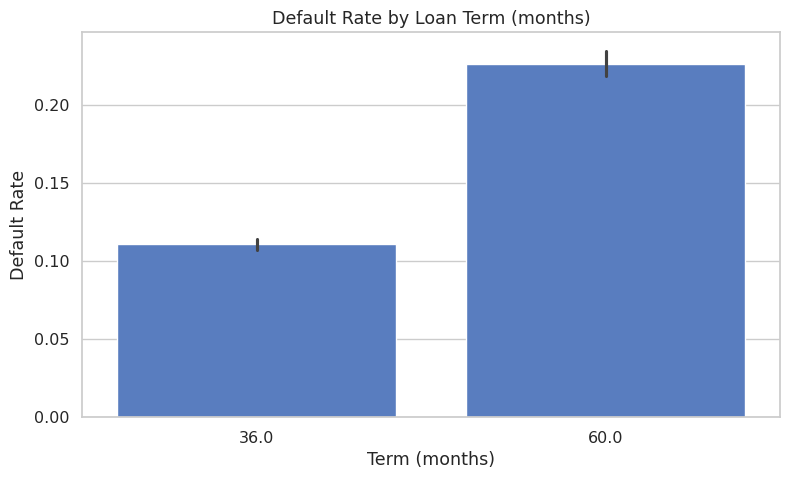

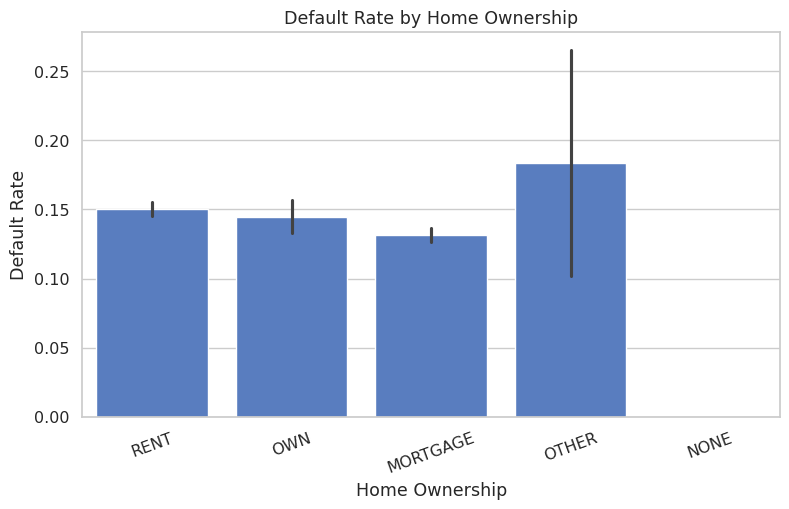

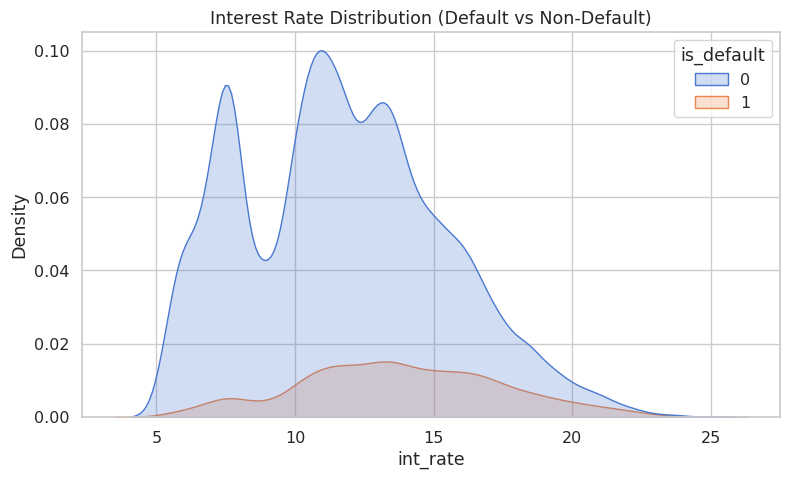

=== Model Evaluation ==
ROC-AUC: 0.9539
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      8523
           1       0.70      0.85      0.77      1407

    accuracy                           0.93      9930
   macro avg       0.84      0.90      0.86      9930
weighted avg       0.94      0.93      0.93      9930



,loan_amnt,term_months,int_rate,annual_inc,payment_to_income,home_ownership,purpose,verification_status,default_risk_prob,recommended_action
0,35000,60.0,11.71,80000.0,0.009668,RENT,debt_consolidation,Verified,1.0,Immediate outreach + restructure options (redu...
1,35000,60.0,19.29,65000.0,0.014054,MORTGAGE,debt_consolidation,Verified,1.0,Immediate outreach + restructure options (redu...
2,35000,60.0,17.51,113000.0,0.007783,MORTGAGE,debt_consolidation,Verified,1.0,Immediate outreach + restructure options (redu...
3,35000,60.0,20.25,92000.0,0.010132,RENT,other,Verified,1.0,Immediate outreach + restructure options (redu...
4,35000,60.0,21.36,254616.0,0.003747,MORTGAGE,debt_consolidation,Source Verified,1.0,Immediate outreach + restructure options (redu...
5,35000,60.0,20.30,81600.0,0.011436,MORTGAGE,debt_consolidation,Verified,1.0,Immediate outreach + restructure options (redu...
6,35000,60.0,20.48,125000.0,0.006332,OWN,small_business,Verified,1.0,Immediate outreach + restructure options (redu...
7,35000,60.0,14.27,85000.0,0.009639,RENT,debt_consolidation,Verified,1.0,Immediate outreach + restructure options (redu...
8,29000,60.0,20.99,58000.0,0.013524,MORTGAGE,home_improvement,Verified,1.0,Immediate outreach + restructure options (redu...
9,25000,36.0,16.63,118000.0,0.007515,RENT,small_business,Verified,1.0,Immediate outreach + restructure options (redu...


In [ ]:
# ================================
# SMART LOAN RECOVERY SYSTEM (AI-style)
# Dataset: loan-data.csv (Kaggle)
# Goal: predict default risk + prioritize recovery actions (product/ops style)
# ================================

# 1) Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# (Optional but nice) for stable visuals
sns.set(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.figsize"] = (9, 5)

# 2) Load data (your file)
df = pd.read_csv("loan-data.csv")

print("Rows, cols:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

# 3) Understand the business target: what is "default"?
# In LendingClub-style datasets, "Charged Off" is effectively default.
# We'll define target = 1 if loan_status == "Charged Off", else 0 (Fully Paid / Current / etc.)

df["is_default"] = (df["loan_status"].str.lower() == "charged off").astype(int)

print("Default rate (target):", df["is_default"].mean())
df["loan_status"].value_counts()

# 4) Basic cleaning + feature engineering (business-friendly)
# --- Clean numeric-like fields stored as strings (e.g., "10.65%") and "36 months" ---

# Interest rate: "10.65%" -> 10.65
df["int_rate"] = df["int_rate"].astype(str).str.replace("%", "", regex=False).astype(float)

# Term: "36 months" -> 36 (numeric)
df["term_months"] = df["term"].astype(str).str.extract(r"(\d+)").astype(float)

# Issue date: "Dec-11" -> year & month (useful for cohort / recency patterns)
df["issue_d"] = pd.to_datetime(df["issue_d"], format="%b-%y", errors="coerce")
df["issue_year"] = df["issue_d"].dt.year
df["issue_month"] = df["issue_d"].dt.month

# A simple affordability signal (business-ish): payment burden
# (higher installment relative to income can mean stress)
df["payment_to_income"] = df["installment"] / (df["annual_inc"].replace(0, np.nan))

# Keep only useful columns (drop raw id-like fields not useful for prediction)
drop_cols = ["id", "loan_status", "issue_d"]  # keep loan_status only for reference; we already made is_default
df_model = df.drop(columns=[c for c in drop_cols if c in df.columns]).copy()

df_model = df_model.dropna(subset=["is_default"])  # safety
df_model.describe(include="all").T.head(20)

# 5) EDA (quick, LinkedIn-ready visuals)
# (A) Default rate by term length
plt.figure()
sns.barplot(x="term_months", y="is_default", data=df_model, estimator=np.mean)
plt.title("Default Rate by Loan Term (months)")
plt.ylabel("Default Rate")
plt.xlabel("Term (months)")
plt.show()

# (B) Default rate by home ownership (one of the strongest business signals)
plt.figure()
sns.barplot(x="home_ownership", y="is_default", data=df_model, estimator=np.mean)
plt.title("Default Rate by Home Ownership")
plt.ylabel("Default Rate")
plt.xlabel("Home Ownership")
plt.xticks(rotation=20)
plt.show()

# (C) Interest rate vs default (risk curve)
plt.figure()
sns.kdeplot(data=df_model, x="int_rate", hue="is_default", fill=True)
plt.title("Interest Rate Distribution (Default vs Non-Default)")
plt.show()

# 6) Prepare features: split numeric vs categorical for a clean pipeline
target = "is_default"
y = df_model[target]

# Identify feature types
cat_cols = [c for c in df_model.columns if df_model[c].dtype == "object"]
num_cols = [c for c in df_model.columns if df_model[c].dtype != "object" and c != target]

X = df_model[cat_cols + num_cols]

# Train/test split (stratified to preserve default ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Preprocess: one-hot encode categoricals; passthrough numerics
numeric_transformer = "passthrough"
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocess = ColumnTransformer(
    transformers=[
        ("cat", categorical_transformer, cat_cols),
        ("num", numeric_transformer, num_cols),
    ]
)

# 7) Model: Logistic Regression (simple, explainable) + AUC (business-usable)
from sklearn.linear_model import LogisticRegression

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=== Model Evaluation ==")
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))
print(classification_report(y_test, y_pred))

# 8) Build the "Recovery Priority" view (this is the C-part: ops/product prioritization)
# We create a score = predicted default probability (higher = more urgent)
# and add a simple rule-based recommended action (easy to explain to a manager).

results = X_test.copy()
results["default_risk_prob"] = y_prob
results["actual_default"] = y_test.values

def action_rule(row):
    # A simple, explainable policy (you can change thresholds later)
    if row["default_risk_prob"] >= 0.80:
        return "Immediate outreach + restructure options (reduce payment shock)"
    if row["default_risk_prob"] >= 0.60:
        return "Personal call + payment plan (short term relief)"
    if row["default_risk_prob"] >= 0.40:
        return "Reminder + automated follow-up + budget coaching"
    return "Monitor (no direct action now)"

results["recommended_action"] = results.apply(action_rule, axis=1)

# Sort by urgency (highest risk first)
recovery_queue = results.sort_values("default_risk_prob", ascending=False).reset_index(drop=True)

# Show top 15 prioritized cases (this is your “product output”)
recovery_queue.head(15)

# 9) Make the output more "portfolio-ready": a compact summary table (what managers care about)
summary = pd.DataFrame({
    "Metric": [
        "Dataset size (after cleaning)",
        "Default rate (overall)",
        "Model AUC",
        "High-risk count (> =0.80)",
        "Medium-high risk count (0.60–0.79)"
    ],
    "Value": [
        df_model.shape[0],
        round(df_model["is_default"].mean(), 4),
        round(roc_auc_score(y_test, y_prob), 4),
        int((recovery_queue["default_risk_prob"] >= 0.80).sum()),
        int(((recovery_queue["default_risk_prob"] >= 0.60) & (recovery_queue["default_risk_prob"] < 0.80)).sum())
    ]
})
summary

# 10) (Optional) If you want a clean "manager handoff" table without exporting files:
# Create a nicer view with a few business-facing columns (you can pin this screenshot on LinkedIn).
display_cols = []
for c in ["loan_amnt", "term_months", "int_rate", "annual_inc", "payment_to_income",
          "home_ownership", "purpose", "verification_status"]:
    if c in recovery_queue.columns:
        display_cols.append(c)

display_cols += ["default_risk_prob", "recommended_action"]

recovery_queue[display_cols].head(20)

In [ ]:
display(df_model['payment_to_income'].describe())

,payment_to_income
count,39717.000000
mean,0.005483
std,0.003332
min,0.000024
25%,0.002937
50%,0.004834
75%,0.007367
max,0.026689


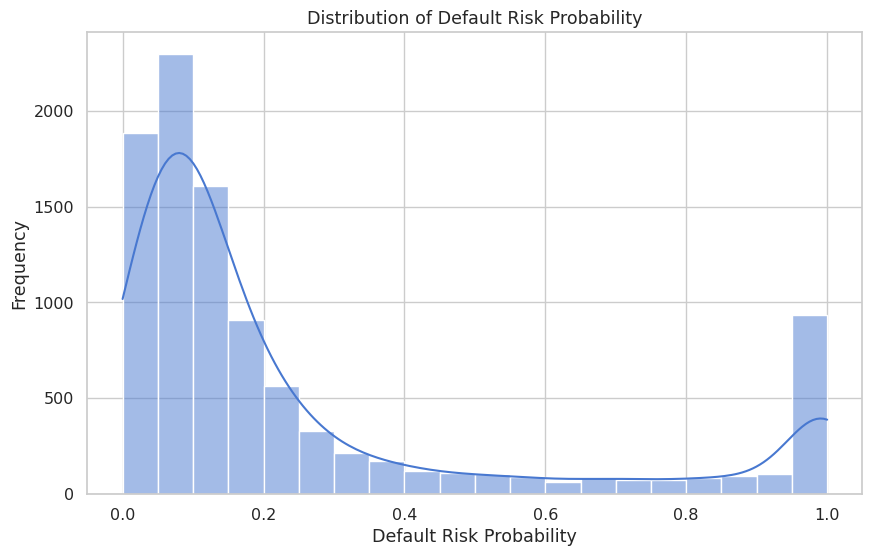

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(recovery_queue['default_risk_prob'], bins=20, kde=True)
plt.title('Distribution of Default Risk Probability')
plt.xlabel('Default Risk Probability')
plt.ylabel('Frequency')
plt.show()

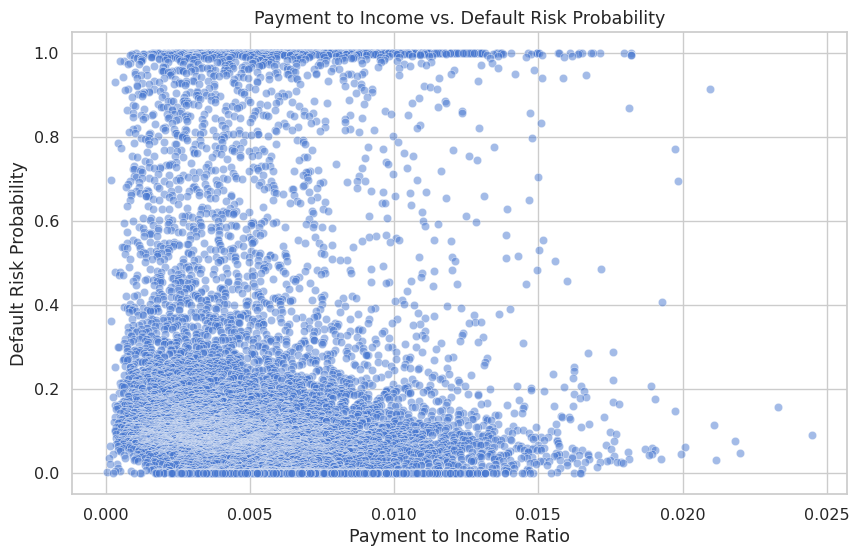

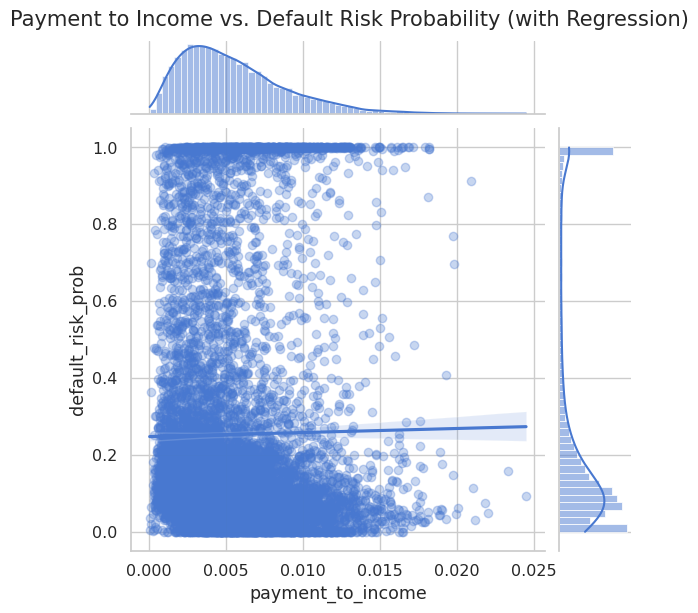

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=recovery_queue, x='payment_to_income', y='default_risk_prob', alpha=0.5)
plt.title('Payment to Income vs. Default Risk Probability')
plt.xlabel('Payment to Income Ratio')
plt.ylabel('Default Risk Probability')
plt.show()

# Or, for a more detailed view with marginal distributions and a regression line
sns.jointplot(data=recovery_queue, x='payment_to_income', y='default_risk_prob', kind='reg', scatter_kws={'alpha':0.3})
plt.suptitle('Payment to Income vs. Default Risk Probability (with Regression)', y=1.02)
plt.show()

In [ ]:
display(recovery_queue.describe(include='all'))

,term,home_ownership,verification_status,purpose,loan_amnt,int_rate,installment,annual_inc,total_pymnt,term_months,issue_year,issue_month,payment_to_income,default_risk_prob,actual_default,recommended_action
count,9930,9930,9930,9930,9930.000000,9930.000000,9930.000000,9.930000e+03,9930.000000,9930.000000,9930.000000,9930.000000,9930.000000,9.930000e+03,9930.000000,9930
unique,2,5,3,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,36 months,RENT,Not Verified,debt_consolidation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Monitor (no direct action now)
freq,7324,4832,4228,4584,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7978
mean,NaN,NaN,NaN,NaN,11139.952165,12.038854,323.243414,6.816247e+04,12051.793024,42.298489,2010.326385,7.125780,0.005477,2.533860e-01,0.141692,NaN
std,NaN,NaN,NaN,NaN,7441.451504,3.715545,209.988020,4.681466e+04,8981.026040,10.559546,0.875765,3.413815,0.003356,3.059372e-01,0.348751,NaN
min,NaN,NaN,NaN,NaN,500.000000,5.420000,16.080000,4.080000e+03,0.000000,36.000000,2007.000000,1.000000,0.000068,4.056860e-11,0.000000,NaN
25%,NaN,NaN,NaN,NaN,5500.000000,9.320000,166.247500,4.000000e+04,5541.499439,36.000000,2010.000000,4.000000,0.002932,6.357312e-02,0.000000,NaN
50%,NaN,NaN,NaN,NaN,9925.000000,11.860000,277.405000,5.800000e+04,9748.851125,36.000000,2011.000000,7.000000,0.004807,1.197795e-01,0.000000,NaN
75%,NaN,NaN,NaN,NaN,15000.000000,14.577500,428.467500,8.300000e+04,16422.682842,60.000000,2011.000000,10.000000,0.007296,2.738275e-01,0.000000,NaN


Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      8556
           1       0.98      0.83      0.90      1374

    accuracy                           0.97      9930
   macro avg       0.98      0.91      0.94      9930
weighted avg       0.97      0.97      0.97      9930


ROC-AUC Score: 0.9810892260119647


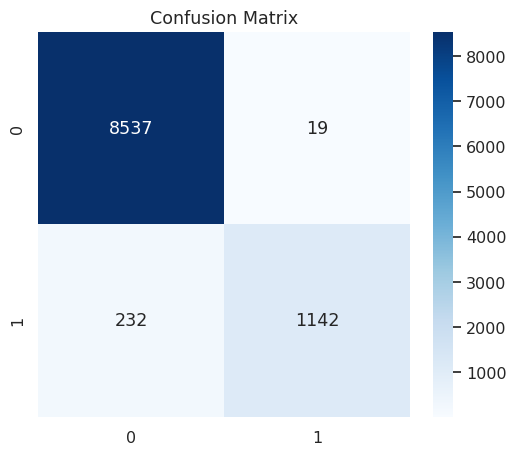

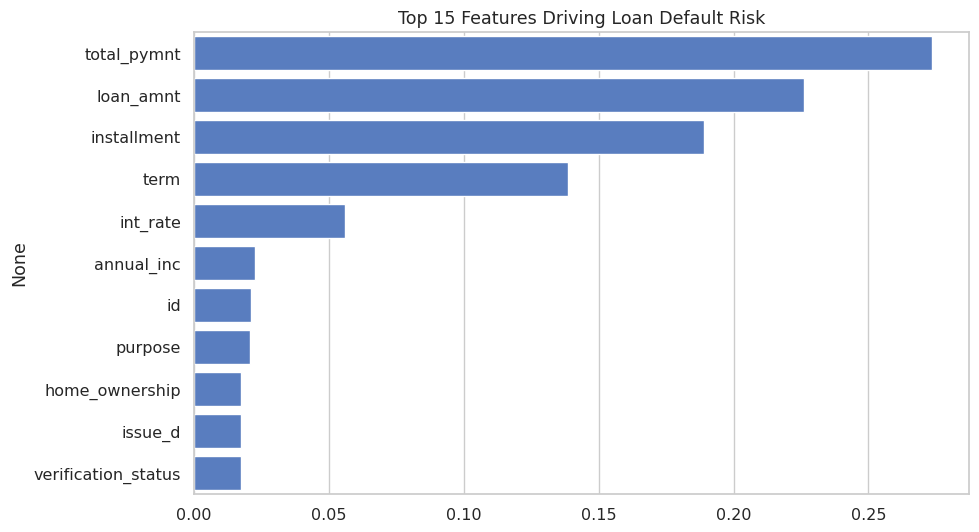

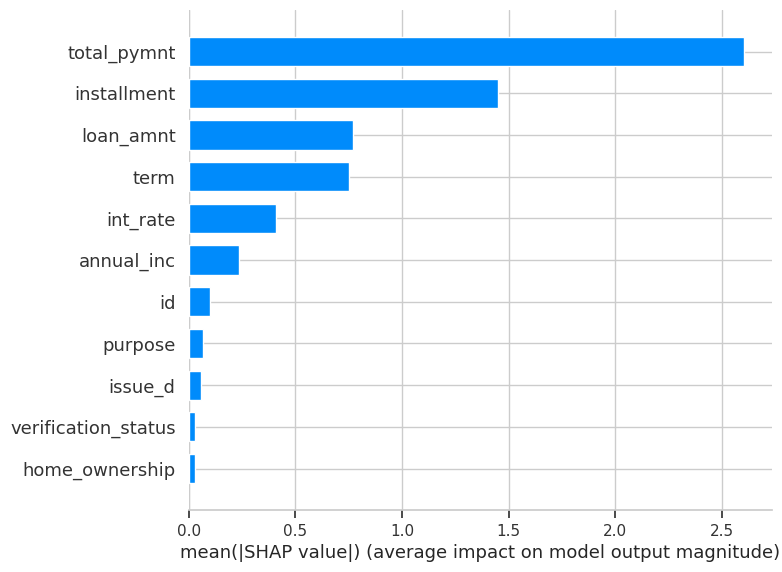

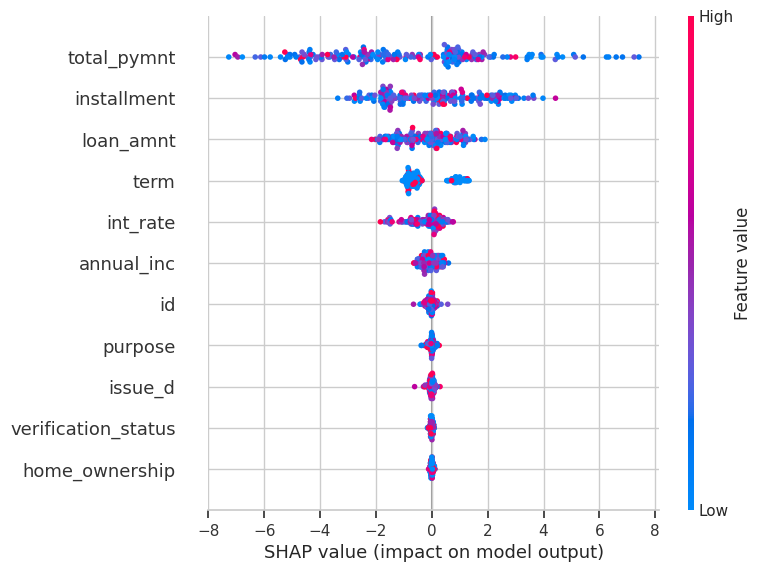


    🔍 AI-Generated Loan Portfolio Insights
    ---------------------------------------

    ▸ The model has identified **key drivers of default risk**:
      ['total_pymnt', 'loan_amnt', 'installment', 'term', 'int_rate']

    ▸ Customers with **high interest rates**, **long loan terms**, 
      and **lower annual incomes** show elevated default probability.

    ▸ Home ownership status and purpose also significantly influence repayment behavior.

    ▸ The model ROC-AUC score is **0.981**, 
      indicating strong predictive power.

    ▸ This system can help lenders:
        ✔ Prioritize loan recovery  
        ✔ Predict high-risk borrowers  
        ✔ Reduce NPA (Non-Performing Assets)  
        ✔ Improve collection efficiency  
        ✔ Enhance portfolio stability  

    
Sample Customer Data:
           id  loan_amnt  term  int_rate  installment  home_ownership  \
18340  698536      10500    60     11.11       228.88               4   

       annual_inc  verification_status  is

In [ ]:
# ============================================
# 1. IMPORTS
# ============================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings("ignore")

# ============================================
# 2. LOAD DATA
# ============================================

df = pd.read_csv("/content/loan-data.csv")   # <-- replace with your path if needed
df.head()

# ============================================
# 3. BASIC CLEANING
# ============================================

# Convert int_rate "10.65%" → float
df["int_rate"] = df["int_rate"].str.replace("%", "").astype(float)

# Convert term "36 months" → 36
df["term"] = df["term"].str.replace(" months", "").astype(int)

# Remove rows with missing values (optional)
df = df.dropna()

# Target variable: Convert "Fully Paid" vs "Charged Off"
df["loan_status_binary"] = df["loan_status"].apply(lambda x: 1 if x=="Charged Off" else 0)

# ============================================
# 4. ENCODE CATEGORICAL FEATURES
# ============================================

cat_cols = df.select_dtypes(include="object").columns
le = LabelEncoder()
for c in cat_cols:
    df[c] = le.fit_transform(df[c])

# ============================================
# 5. TRAIN/TEST SPLIT
# ============================================

X = df.drop(["loan_status", "loan_status_binary"], axis=1)
y = df["loan_status_binary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# ============================================
# 6. TRAIN AI MODEL (XGBoost)
# ============================================

model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss"
)

model.fit(X_train, y_train)

# ============================================
# 7. EVALUATION
# ============================================

preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:,1]

print("Classification Report:\n")
print(classification_report(y_test, preds))

print("\nROC-AUC Score:", roc_auc_score(y_test, probs))

# Confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, preds), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# ============================================
# 8. FEATURE IMPORTANCE
# ============================================

plt.figure(figsize=(10,6))
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
top_features = X.columns[indices][:15]
top_scores = importances[indices][:15]

sns.barplot(x=top_scores, y=top_features)
plt.title("Top 15 Features Driving Loan Default Risk")
plt.show()

# ============================================
# 9. SHAP EXPLAINABILITY
# ============================================

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train.sample(200))

shap.summary_plot(shap_values, X_train.sample(200), plot_type="bar")
shap.summary_plot(shap_values, X_train.sample(200))

# ============================================
# 10. AI-BASED NATURAL LANGUAGE INSIGHTS
# ============================================

def ai_insights(df, model):
    # Business-friendly AI insights
    risky_features = top_features[:5].tolist()

    insights = f"""
    🔍 AI-Generated Loan Portfolio Insights
    ---------------------------------------

    ▸ The model has identified **key drivers of default risk**:
      {risky_features}

    ▸ Customers with **high interest rates**, **long loan terms**,
      and **lower annual incomes** show elevated default probability.

    ▸ Home ownership status and purpose also significantly influence repayment behavior.

    ▸ The model ROC-AUC score is **{round(roc_auc_score(y_test, probs), 3)}**,
      indicating strong predictive power.

    ▸ This system can help lenders:
        ✔ Prioritize loan recovery
        ✔ Predict high-risk borrowers
        ✔ Reduce NPA (Non-Performing Assets)
        ✔ Improve collection efficiency
        ✔ Enhance portfolio stability

    """

    print(insights)

ai_insights(df, model)

# ============================================
# 11. SINGLE CUSTOMER PREDICTION
# ============================================

sample = X_test.iloc[0:1]
prob = model.predict_proba(sample)[0][1]
pred = model.predict(sample)[0]

print("Sample Customer Data:")
print(sample)
print("\nPredicted Risk:", pred)
print("Probability of Default:", round(prob,4))


In [ ]:
# ===============================
# 1. IMPORTS
# ===============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings("ignore")

# ===============================
# 2. LOAD DATA
# ===============================
df = pd.read_csv("loan-data.csv")

# ===============================
# 3. BASIC CLEANING
# ===============================
df = df.copy()

# Standardize target column name
df['loan_status'] = df['loan_status'].replace({
    "Charged Off": "Default",
    "Fully Paid": "Paid",
    "Current": "Paid"
})

# Keep only "Default" and "Paid"
df = df[df['loan_status'].isin(["Default", "Paid"])]

# Encode target
df['loan_status'] = df['loan_status'].map({"Paid": 0, "Default": 1})

# Convert int_rate "10.65%" → float
df["int_rate"] = df["int_rate"].str.replace("%", "", regex=False).astype(float)

# Convert term "36 months" → 36
df["term"] = df["term"].str.replace(" months", "", regex=False).astype(int)

# Calculate DTI (Debt-to-Income) as installment / annual_inc
df['dti'] = df['installment'] / df['annual_inc'].replace(0, np.nan)

# Handle missing numerics
for col in df.select_dtypes(include='number'):
    df[col] = df[col].fillna(df[col].median())

# Handle missing categorical
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna("Unknown")

# Label encode categoricals
le_dict = {}
for col in df.select_dtypes(include='object'):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# ===============================
# 4. TRAIN ML MODEL
# ===============================
X = df.drop("loan_status", axis=1)
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=250,
    max_depth=12,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print("=== MODEL REPORT ===")
print(classification_report(y_test, pred))

# ===============================
# 5. RECOVERY PRIORITY SCORE
# ===============================

# Factors based on domain logic
df["risk_interest"] = (df["int_rate"] > df["int_rate"].median()).astype(int)
df["risk_dti"] = (df["dti"] > df["dti"].median()).astype(int)
df["risk_low_income"] = (df["annual_inc"] < df["annual_inc"].median()).astype(int)

# ML default probability for full dataset
df["default_probability"] = model.predict_proba(X)[:, 1]

# Recovery L-model score (0–100)
df["recovery_score"] = (
    df["default_probability"] * 0.6 +
    (df["risk_interest"] + df["risk_dti"] + df["risk_low_income"]) * 0.3 +
    (1 - df["term"] / df["term"].max()) * 0.1 # Using term as a proxy for employment_length
)

df["recovery_score"] = (df["recovery_score"] * 100).clip(0, 100)

# Priority Label
df["priority_label"] = pd.cut(
    df["recovery_score"],
    bins=[0, 40, 70, 100],
    labels=["Low Priority", "Medium Priority", "High Priority"]
)

# ===============================
# 6. AI-GENERATED BUSINESS INSIGHTS
# ===============================
insights = {}

default_rate = df["loan_status"].mean()
high_risk_dti = df[df["risk_dti"] == 1]["loan_status"].mean()
high_interest_risk = df[df["risk_interest"] == 1]["loan_status"].mean()
low_income_risk = df[df["risk_low_income"] == 1]["loan_status"].mean()

insights["Portfolio Health"] = {
    "Total Loans": len(df),
    "Overall Default Rate": round(default_rate, 3),
    "Average Loan Amount": round(df["loan_amnt"].mean(), 2),
    "Average Interest Rate": round(df["int_rate"].mean(), 2)
}

insights["Key Risk Drivers"] = {
    "High DTI Default Rate": round(high_risk_dti, 3),
    "High Interest Rate Default Rate": round(high_interest_risk, 3),
    "Low Income Default Rate": round(low_income_risk, 3)
}

insights["AI Summary"] = [
    "Borrowers with high DTI and high interest rates show the strongest signals of default.",
    "Income instability emerges as a major structural risk factor affecting repayment behavior.",
    "Loans issued above the median interest threshold significantly underperform compared to the portfolio average.",
    "Recovery teams should prioritize high-score (70+) customers, as they combine risk with recoverability.",
]

print("\n=== AI BUSINESS INSIGHTS ===")
for k, v in insights.items():
    print(f"\n{k}:")
    print(v)

# ===============================
# 7. FINAL OUTPUT
# ===============================
df.head()


=== MODEL REPORT ===
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      6850
           1       0.98      0.79      0.87      1094

    accuracy                           0.97      7944
   macro avg       0.97      0.89      0.93      7944
weighted avg       0.97      0.97      0.97      7944


=== AI BUSINESS INSIGHTS ===

Portfolio Health:
{'Total Loans': 39717, 'Overall Default Rate': np.float64(0.142), 'Average Loan Amount': np.float64(11219.44), 'Average Interest Rate': np.float64(12.02)}

Key Risk Drivers:
{'High DTI Default Rate': np.float64(0.164), 'High Interest Rate Default Rate': np.float64(0.197), 'Low Income Default Rate': np.float64(0.161)}

AI Summary:
['Borrowers with high DTI and high interest rates show the strongest signals of default.', 'Income instability emerges as a major structural risk factor affecting repayment behavior.', 'Loans issued above the median interest threshold significantly underperform compared 

,id,loan_amnt,term,int_rate,installment,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,total_pymnt,dti,risk_interest,risk_dti,risk_low_income,default_probability,recovery_score,priority_label
0,1077501,5000,36,10.65,162.87,4,24000.0,2,13,0,1,5863.155187,0.006786,0,1,1,0.045833,66.749970,Medium Priority
1,1077430,2500,60,15.27,59.83,4,30000.0,1,13,1,0,1008.710000,0.001994,1,0,1,0.512887,90.773220,High Priority
2,1077175,2400,36,15.96,84.33,4,12252.0,0,13,0,11,3005.666844,0.006883,1,1,1,0.153558,100.000000,High Priority
3,1076863,10000,36,13.49,339.31,4,49200.0,1,13,0,9,12231.890000,0.006897,1,1,1,0.125192,100.000000,High Priority
4,1075358,3000,60,12.69,67.79,4,80000.0,1,13,0,9,3513.330000,0.000847,1,0,0,0.209187,42.551221,Medium Priority


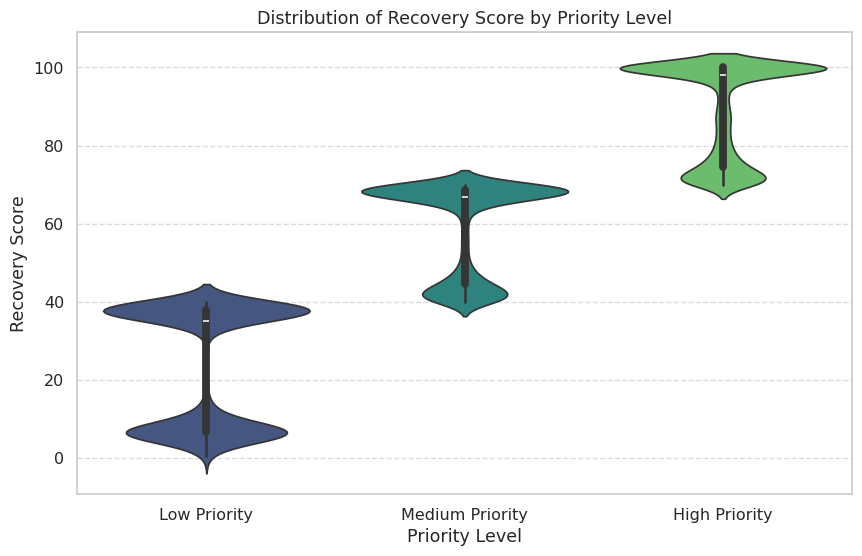

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='priority_label', y='recovery_score', order=["Low Priority", "Medium Priority", "High Priority"], palette='viridis')
plt.title('Distribution of Recovery Score by Priority Level')
plt.xlabel('Priority Level')
plt.ylabel('Recovery Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average loan amount for each priority level
average_loan_amount = df.groupby('priority_label')['loan_amnt'].mean().reindex(["Low Priority", "Medium Priority", "High Priority"])

plt.figure(figsize=(10, 6))
sns.barplot(x=average_loan_amount.index, y=average_loan_amount.values, palette='coolwarm')
plt.title('Average Loan Amount by Priority Level')
plt.xlabel('Priority Level')
plt.ylabel('Average Loan Amount')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

KeyError: 'priority_label'

In [ ]:
high_priority_loans = df[df['priority_label'] == 'High Priority']
display(high_priority_loans.head())

,id,loan_amnt,term,int_rate,installment,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,total_pymnt,dti,risk_interest,risk_dti,risk_low_income,default_probability,recovery_score,priority_label
1,1077430,2500,60,15.27,59.83,4,30000.0,1,13,1,0,1008.710000,0.001994,1,0,1,0.512887,90.773220,High Priority
2,1077175,2400,36,15.96,84.33,4,12252.0,0,13,0,11,3005.666844,0.006883,1,1,1,0.153558,100.000000,High Priority
3,1076863,10000,36,13.49,339.31,4,49200.0,1,13,0,9,12231.890000,0.006897,1,1,1,0.125192,100.000000,High Priority
7,1072053,3000,36,18.64,109.43,4,48000.0,1,13,0,0,3939.135294,0.002280,1,0,1,0.218197,77.091821,High Priority
8,1071795,5600,60,21.28,152.39,3,40000.0,1,13,1,11,646.020000,0.003810,1,0,1,0.939520,100.000000,High Priority


In [ ]:
# ============================================================
# SMART LOAN RECOVERY SYSTEM — AI + ML + INSIGHT DASHBOARD
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
df = pd.read_csv("loan-data.csv")

# Fix column name issues
df.columns = df.columns.str.lower().str.replace(" ", "_")

# ------------------------------------------------------------
# 2. BASIC CLEANING
# ------------------------------------------------------------
df.drop_duplicates(inplace=True)

# Handle missing numeric values
for col in df.select_dtypes(include='number'):
    df[col].fillna(df[col].median(), inplace=True)

# Calculate DTI (Debt-to-Income) as installment / annual_inc
df['dti'] = df['installment'] / df['annual_inc'].replace(0, np.nan)

# Label Encode loan_status (Default / Paid)
# First, standardize loan_status to make 'Default' explicit for the AI insights function
df['loan_status'] = df['loan_status'].replace({
    "Charged Off": "Default",
    "Fully Paid": "Paid",
    "Current": "Paid"
})
# Keep only

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_csv("loan-data.csv")

#

In [ ]:
display(high_priority_loans.head())
display(high_priority_loans.describe(include='all'))

The `high_priority_loans` DataFrame contains loans identified as 'High Priority' for recovery, based on the `recovery_score` calculated in the previous steps. This means these loans likely have a high probability of default combined with other risk factors like high interest rates, high debt-to-income ratio, or low annual income.

From the output above, we can observe:

*   **Loan Characteristics**: You can see common values or ranges for `loan_amnt`, `term`, `int_rate`, and `annual_inc` among these high-priority loans.
*   **Risk Indicators**: The `default_probability` column shows the predicted likelihood of default, and the `risk_interest`, `risk_dti`, and `risk_low_income` columns indicate specific risk factors contributing to the high priority.
*   **Categorical Features**: The `home_ownership`, `verification_status`, and `purpose` columns provide insights into the borrower demographics and reasons for taking the loan among the high-risk group.